# Analysing Data Distributions
In the final stages of this part of the project, we need to determine what are reasonable thresholds or top numbers of contacts to use for optimal transport. Thus, we'll import all bulk and single cell datasets and visualize the distributions of data.

## Imports

In [1]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [2]:
### Directories and Files ###
root = '../../'
data_dir_immune = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data' # Importing was not working with relative root+'..' approach, so replace with local data
data_dir_lines = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/ramani_cool_files'
data_dir_bulk = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/taghic'

In [10]:
### Imports ###
import sys
import cooler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, hic_calculate_deviance

In [4]:
### Importing coolers ###
clrs_immune = import_cool_dir(data_dir_immune)
clrs_lines = import_cool_dir(data_dir_lines)
clrs_bulk = import_cool_dir(data_dir_bulk, 1_000_000)

## Helper Functions

In [5]:
def extract_counts(
        coolers : list[cooler.Cooler],
        label : str="chr1"):
    '''
        Extracts all values and only the values in chromosome 1
        for a list of coolers.

        Parameters
        ----------
        coolers : list[cooler.Cooler]
            List of coolers.
        label : str
            Label for chromosome 1 to extract from the coolers.
            Default = "chr1"
        
        Returns
        all_counts : list[float]
            Maximum normalized list of count values across
            all chromosomes for all coolers.
        chr1_counts : list[float]
            Maximum normalized list of count values for
            chromosome 1 across all coolers.
    '''
    # Initializing empty lists
    all_counts = []
    chr1_counts = []

    for clr in coolers:
        # All chromosomes
        pixels = clr.pixels()[:]
        all_counts.append(pixels["count"].values)

        # Only chromosome 1
        pixels_chr1 = clr.pixels().fetch(label)
        chr1_counts.append(pixels_chr1["count"].values)

    # Converting to flat array
    all_counts = np.concatenate(all_counts)
    chr1_counts = np.concatenate(chr1_counts)

    # Maximum normalizing
    all_counts = all_counts / np.max(all_counts)
    chr1_counts = chr1_counts / np.max(chr1_counts)

    return all_counts, chr1_counts

## Extracting Counts

In [ ]:
### Standard counts ###
# Immune cells
immune_all, immune_chr1 = extract_counts(clrs_immune)

# Cell Lines
lines_all, lines_chr1 = extract_counts(clrs_lines)

# Bulk
bulk_all, bulk_chr1 = extract_counts(clrs_bulk, "1")

In [ ]:
### Deviance ###
# Immune cells
immune_dev_all = []
immune_dev_chr1 = []
for chr in clrs_immune[0].chromnames:
    print("Calculating deviance for chromosome:", chr)
    immune_dev_all.append(hic_calculate_deviance(clrs_immune, chr))
immune_dev_chr1 = immune_dev_all[0]["deviances"].values
immune_dev_all = np.concatenate(immune_dev_all)

# Cell Lines
lines_dev_all = []
lines_dev_chr1 = []
for chr in clrs_lines[0].chromnames:
    print("Calculating deviance for chromosome:", chr)
    lines_dev_all.append(hic_calculate_deviance(clrs_lines, chr))
lines_dev_chr1 = lines_dev_all[0]["deviances"].values
lines_dev_all = np.concatenate(lines_dev_all)

# Bulk
bulk_dev_all = []
bulk_dev_chr1 = []
for chr in clrs_bulk[0].chromnames:
    print("Calculating deviance for chromosome:", chr)
    bulk_dev_all.append(hic_calculate_deviance(clrs_bulk, chr))
bulk_dev_chr1 = bulk_dev_all[0]["deviances"].values
bulk_dev_all = np.concatenate(bulk_dev_all)

# Maximum normalizing
immune_dev_all = immune_dev_all / np.max(immune_dev_all)
immune_dev_chr1 = immune_dev_chr1 / np.max(immune_dev_chr1)
lines_dev_all = lines_dev_all / np.max(lines_dev_all)
lines_dev_chr1 = lines_dev_chr1 / np.max(lines_dev_chr1)
bulk_dev_all = bulk_dev_all / np.max(bulk_dev_all)
bulk_dev_chr1 = bulk_dev_chr1 / np.max(bulk_dev_chr1)

Calculating deviance for chromosome: chr1
Calculating deviance for chromosome: chr2
Calculating deviance for chromosome: chr3
Calculating deviance for chromosome: chr4
Calculating deviance for chromosome: chr5
Calculating deviance for chromosome: chr6
Calculating deviance for chromosome: chr7
Calculating deviance for chromosome: chr8
Calculating deviance for chromosome: chr9
Calculating deviance for chromosome: chr10
Calculating deviance for chromosome: chr11
Calculating deviance for chromosome: chr12
Calculating deviance for chromosome: chr13
Calculating deviance for chromosome: chr14
Calculating deviance for chromosome: chr15
Calculating deviance for chromosome: chr16
Calculating deviance for chromosome: chr17
Calculating deviance for chromosome: chr18
Calculating deviance for chromosome: chr19
Calculating deviance for chromosome: chr20
Calculating deviance for chromosome: chr21
Calculating deviance for chromosome: chr22
Calculating deviance for chromosome: chrX
Calculating deviance 

/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Data Features/../../Scripts/hicdatautils/hicot.py:408: RuntimeWarning: divide by zero encountered in log1p
  log1P = np.log1p(-P)
/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Data Features/../../Scripts/hicdatautils/hicot.py:411: RuntimeWarning: invalid value encountered in multiply
  X * logP + (sz - X) * log1P,
/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Data Features/../../Scripts/hicdatautils/hicot.py:425: RuntimeWarning: divide by zero encountered in log1p
  log1p = np.log1p(-p)
/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Testing/Data Features/../../Scripts/hicdatautils/hicot.py:427: RuntimeWarning: invalid value encountered in multiply
  ll_null = feature_sums * logp + (sz_sum - feature_sums) * log1p


## Visualizing Normalized Counts

In [30]:
### Setting lists ###
datasets_all = [immune_all, lines_all, bulk_all]
datasets_chr1 = [immune_chr1, lines_chr1, bulk_chr1]
dev_all = [immune_dev_all, lines_dev_all, bulk_dev_all]
dev_chr1 = [immune_dev_chr1, lines_dev_chr1, bulk_dev_chr1]
labels = ["Immune Cells", "Cell Lines", "Bulk"]

Text(0.5, 0.98, 'Data Distribution, Standard Data')

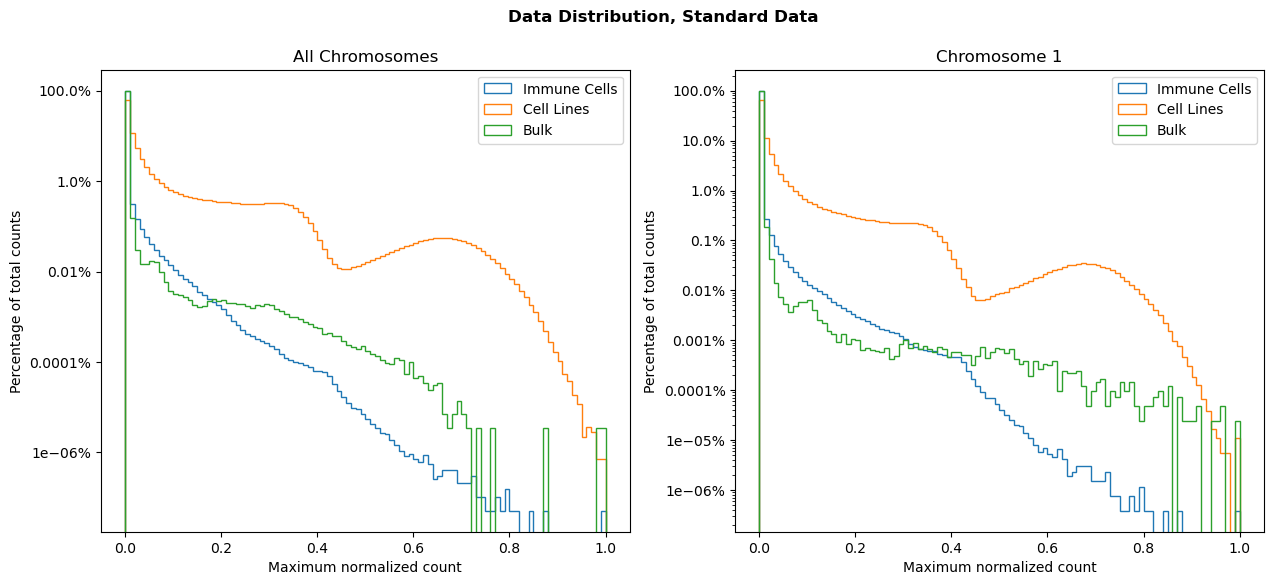

In [28]:
### Standard Data ###
fig, ax = plt.subplots(1, 2, figsize=(15,6))

# All Chromosomes
for data, label in zip(datasets_all, labels):
    weights = np.ones(len(data)) / len(data) * 100
    ax[0].hist(
        data,
        bins=100,
        weights=weights,
        log=True,
        label=label,
        histtype="step"
    )

ax[0].legend()
ax[0].set_ylabel("Percentage of total counts")
ax[0].set_xlabel("Maximum normalized count")
ax[0].set_title("All Chromosomes")

# Chromosome 1
for data, label in zip(datasets_chr1, labels):
    weights = np.ones(len(data)) / len(data) * 100
    ax[1].hist(
        data,
        bins=100,
        weights=weights,
        log=True,
        label=label,
        histtype="step"
    )

ax[1].legend()
ax[1].set_ylabel("Percentage of total counts")
ax[1].set_xlabel("Maximum normalized count")
ax[1].set_title("Chromosome 1")

# Overall formatting
ax[0].yaxis.set_major_formatter(StrMethodFormatter("{x}%"))
ax[1].yaxis.set_major_formatter(StrMethodFormatter("{x}%"))
plt.suptitle("Data Distribution, Standard Data", fontweight='bold')

Text(0.5, 0.98, 'Data Distribution, Deviance')

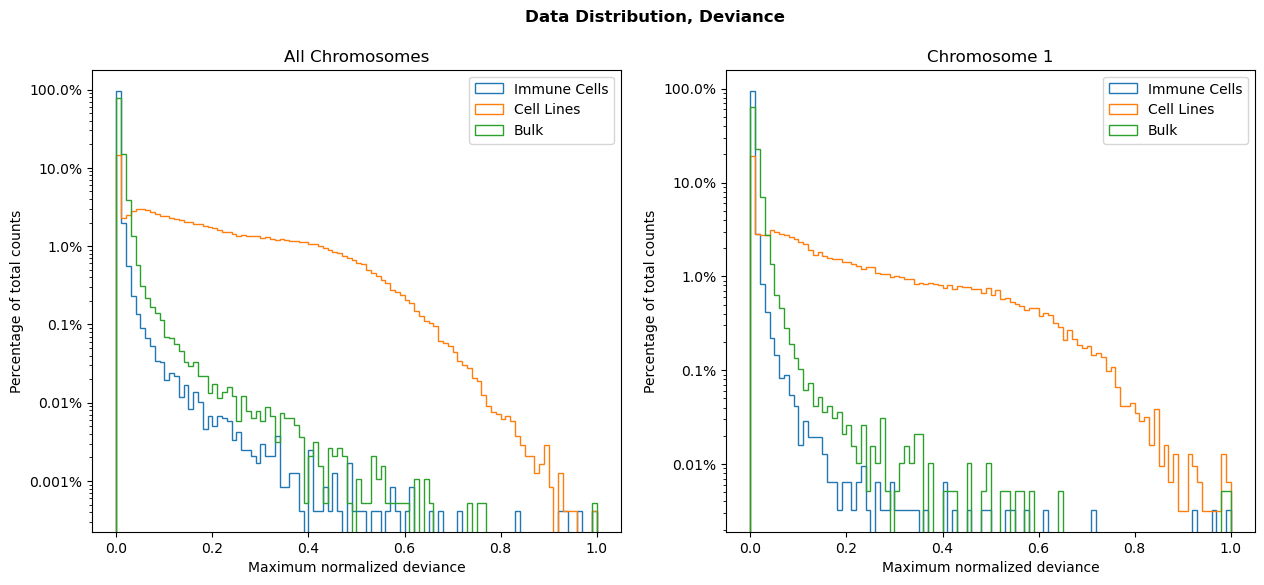

In [31]:
### Standard Data ###
fig, ax = plt.subplots(1, 2, figsize=(15,6))

# All Chromosomes
for data, label in zip(dev_all, labels):
    weights = np.ones(len(data)) / len(data) * 100
    ax[0].hist(
        data,
        bins=100,
        weights=weights,
        log=True,
        label=label,
        histtype="step"
    )

ax[0].legend()
ax[0].set_ylabel("Percentage of total counts")
ax[0].set_xlabel("Maximum normalized deviance")
ax[0].set_title("All Chromosomes")

# Chromosome 1
for data, label in zip(dev_chr1, labels):
    weights = np.ones(len(data)) / len(data) * 100
    ax[1].hist(
        data,
        bins=100,
        weights=weights,
        log=True,
        label=label,
        histtype="step"
    )

ax[1].legend()
ax[1].set_ylabel("Percentage of total counts")
ax[1].set_xlabel("Maximum normalized deviance")
ax[1].set_title("Chromosome 1")

# Overall formatting
ax[0].yaxis.set_major_formatter(StrMethodFormatter("{x}%"))
ax[1].yaxis.set_major_formatter(StrMethodFormatter("{x}%"))
plt.suptitle("Data Distribution, Deviance", fontweight='bold')